# IT2011 – Breast Cancer Wisconsin (Original)

## Member 04 – Feature Scaling

### Main Focus
- Feature Scaling
- Standardization using StandardScaler
- Before vs After Scaling Analysis

### Dataset
UCI Breast Cancer Wisconsin (Original)

In [6]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
# ============================================
# PROJECT PATH SETUP
# ============================================

# Import Path for safe file and folder handling.
from pathlib import Path

# Detect the folder where this notebook is currently running.
CURRENT_DIR = Path.cwd()

# If running from the "notebooks" folder,
# move one level up to reach the main project folder.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Create the path to the shared raw dataset.
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "breast-cancer-wisconsin.data"
)

# Verify that the correct project and dataset paths were detected.
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\gayan\Documents\AI
Dataset path: c:\Users\gayan\Documents\AI\data\raw\breast-cancer-wisconsin.data
Dataset exists: True


In [8]:
# ============================================
# STEP 2 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [9]:
# ============================================
# STEP 3 - Load the raw dataset
# ============================================

# Load the raw dataset from the shared data/raw folder.
# DATA_PATH was created earlier using PROJECT_ROOT.
df = pd.read_csv(
    DATA_PATH,
    header=None
)

# Confirm that the dataset loaded successfully.
print("Dataset loaded successfully.")
print("Shape:", df.shape)

# Preview the first five rows.
df.head()

Dataset loaded successfully.
Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [10]:
# ============================================
# STEP 4 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [11]:
# ============================================
# STEP 5 - Check the dataset structure
# ============================================

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing value markers:")
print((df == "?").sum())

Dataset shape: (699, 11)

Data types:
Sample_ID                      int64
Clump_Thickness                int64
Uniformity_Cell_Size           int64
Uniformity_Cell_Shape          int64
Marginal_Adhesion              int64
Single_Epithelial_Cell_Size    int64
Bare_Nuclei                      str
Bland_Chromatin                int64
Normal_Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object

Missing value markers:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [12]:
# ============================================
# STEP 6 - Replace '?' with NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [13]:
# ============================================
# STEP 7 - Convert Bare_Nuclei to numeric
# ============================================

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print(df.dtypes)

Sample_ID                        int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object


In [14]:
# ============================================
# STEP 8 - Define the predictor features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

X = df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", X.shape)

X.head()

Number of features: 9
Feature matrix shape: (699, 9)


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [15]:
# ============================================
# STEP 9 - Encode the target variable
# ============================================

y = df["Class"].map({
    2: 0,   # Benign
    4: 1    # Malignant
})

print("Encoded target values:")
print(y.value_counts().sort_index())

Encoded target values:
Class
0    458
1    241
Name: count, dtype: int64


In [16]:
# ============================================
# STEP 10 - Check feature ranges before scaling
# ============================================

before_scaling = X.describe().T[
    ["min", "max", "mean", "std"]
]

before_scaling

,min,max,mean,std
Clump_Thickness,1.0,10.0,4.417740,2.815741
Uniformity_Cell_Size,1.0,10.0,3.134478,3.051459
Uniformity_Cell_Shape,1.0,10.0,3.207439,2.971913
Marginal_Adhesion,1.0,10.0,2.806867,2.855379
Single_Epithelial_Cell_Size,1.0,10.0,3.216023,2.214300
Bare_Nuclei,1.0,10.0,3.544656,3.643857
Bland_Chromatin,1.0,10.0,3.437768,2.438364
Normal_Nucleoli,1.0,10.0,2.866953,3.053634
Mitoses,1.0,10.0,1.589413,1.715078


## Why Feature Scaling?

Feature scaling puts numerical features onto a common scale.

In this project, StandardScaler is used because:

- Logistic Regression can be affected by feature scale.
- SVM is sensitive to feature scale because it uses distances/margins.
- PCA is strongly affected by feature variance.
- Standardization allows the features to contribute on a comparable scale.

StandardScaler transforms each feature so that:

- Mean ≈ 0
- Standard deviation ≈ 1

The transformation is:

z = (x - mean) / standard deviation

The scaling parameters should be learned from the training data when building the final ML model to avoid data leakage.

In [17]:
# ============================================
# STEP 12 - Apply StandardScaler
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Scaling completed.
Scaled data shape: (699, 9)


In [18]:
# ============================================
# STEP 13 - Create a DataFrame for scaled data
# ============================================

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_columns,
    index=X.index
)

X_scaled_df.head()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,0.206936,-0.699995,-0.743299,-0.633247,-0.549561,-0.698853,-0.179662,-0.611825,-0.343912
1,0.206936,0.283845,0.266875,0.768621,1.710106,1.772867,-0.179662,-0.284112,-0.343912
2,-0.503866,-0.699995,-0.743299,-0.633247,-0.549561,-0.424217,-0.179662,-0.611825,-0.343912
3,0.562336,1.595632,1.613773,-0.633247,-0.097628,0.125054,-0.179662,1.354454,-0.343912
4,-0.148465,-0.699995,-0.743299,0.067687,-0.549561,-0.698853,-0.179662,-0.611825,-0.343912


In [19]:
# ============================================
# STEP 14 - Check feature statistics after scaling
# ============================================

after_scaling = X_scaled_df.describe().T[
    ["min", "max", "mean", "std"]
]

after_scaling

,min,max,mean,std
Clump_Thickness,-1.214667,1.983939,-5.082566e-17,1.000716
Uniformity_Cell_Size,-0.699995,2.251526,-9.148619e-17,1.000716
Uniformity_Cell_Shape,-0.743299,2.287222,-3.049540e-17,1.000716
Marginal_Adhesion,-0.633247,2.520955,5.082566e-17,1.000716
Single_Epithelial_Cell_Size,-1.001495,3.065906,5.082566e-17,1.000716
Bare_Nuclei,-0.698853,1.772867,0.000000e+00,1.000733
Bland_Chromatin,-1.000471,2.693171,3.049540e-17,1.000716
Normal_Nucleoli,-0.611825,2.337594,-1.321467e-16,1.000716
Mitoses,-0.343912,4.907421,-8.132106e-17,1.000716


In [20]:
# ============================================
# STEP 15 - Compare before and after scaling
# ============================================

comparison = pd.DataFrame({
    "Before_Mean": X.mean(),
    "Before_Std": X.std(),
    "After_Mean": X_scaled_df.mean(),
    "After_Std": X_scaled_df.std()
})

comparison

,Before_Mean,Before_Std,After_Mean,After_Std
Clump_Thickness,4.417740,2.815741,-5.082566e-17,1.000716
Uniformity_Cell_Size,3.134478,3.051459,-9.148619e-17,1.000716
Uniformity_Cell_Shape,3.207439,2.971913,-3.049540e-17,1.000716
Marginal_Adhesion,2.806867,2.855379,5.082566e-17,1.000716
Single_Epithelial_Cell_Size,3.216023,2.214300,5.082566e-17,1.000716
Bare_Nuclei,3.544656,3.643857,0.000000e+00,1.000733
Bland_Chromatin,3.437768,2.438364,3.049540e-17,1.000716
Normal_Nucleoli,2.866953,3.053634,-1.321467e-16,1.000716
Mitoses,1.589413,1.715078,-8.132106e-17,1.000716


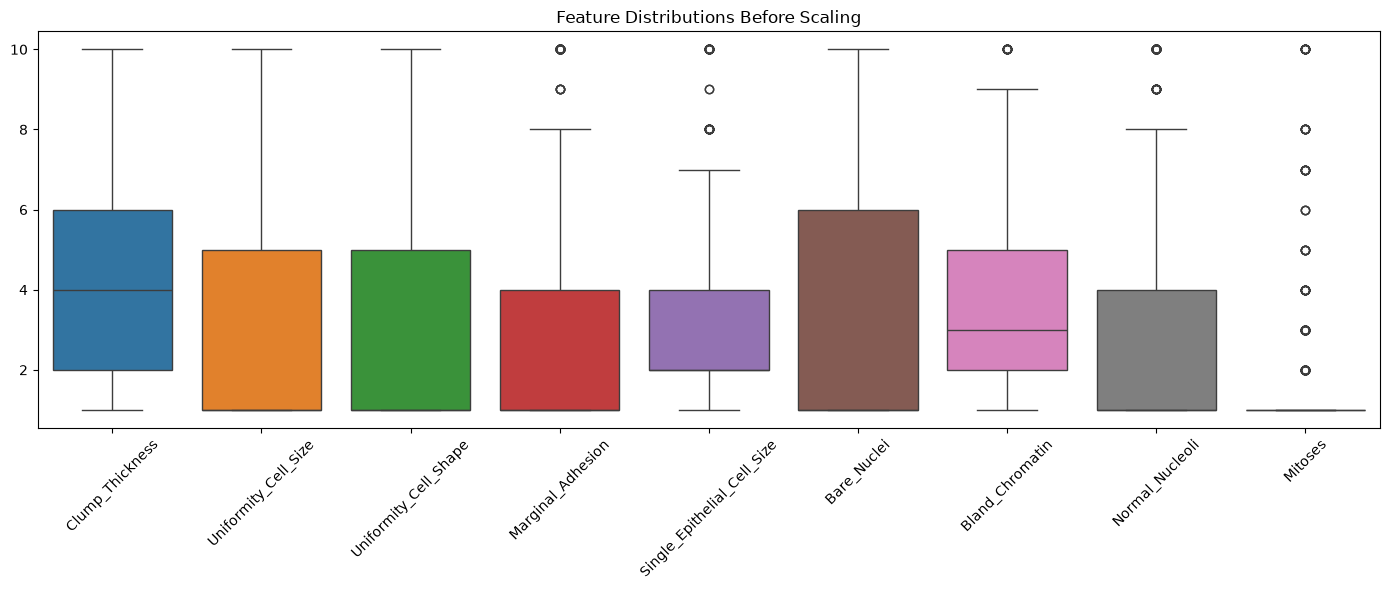

In [21]:
# ============================================
# STEP 16 - Visualize feature distributions before scaling
# ============================================

plt.figure(figsize=(14, 6))

sns.boxplot(data=X)

plt.title("Feature Distributions Before Scaling")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

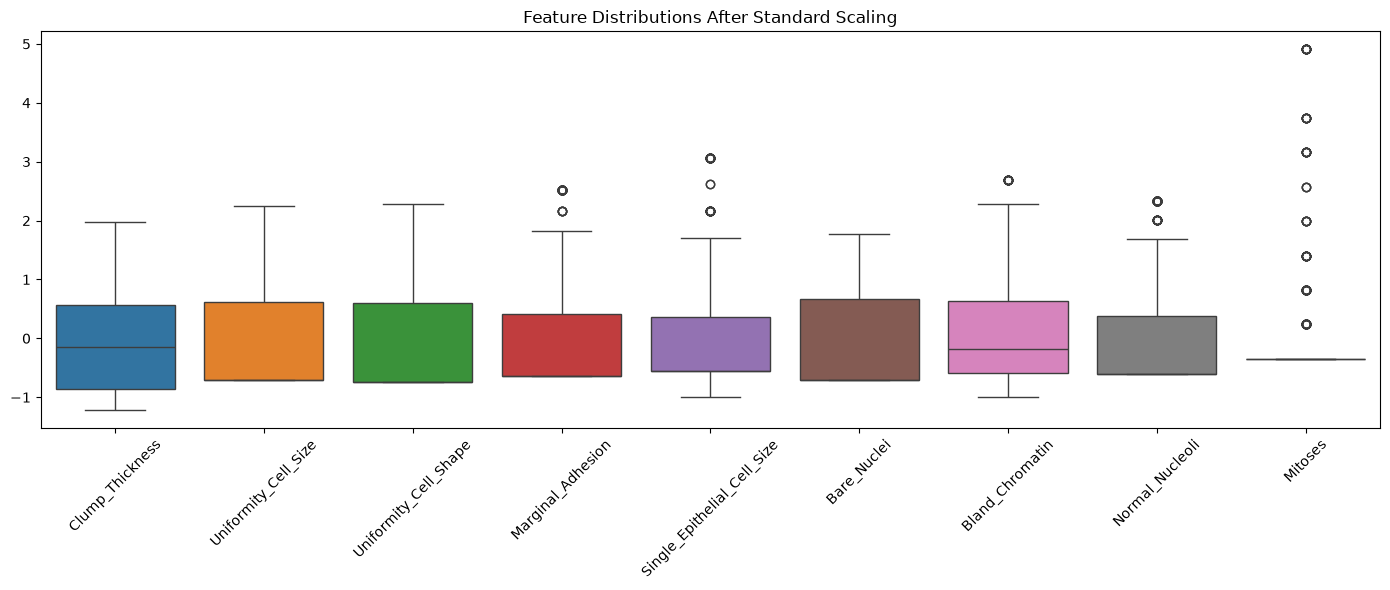

In [22]:
# ============================================
# STEP 17 - Visualize feature distributions after scaling
# ============================================

plt.figure(figsize=(14, 6))

sns.boxplot(data=X_scaled_df)

plt.title("Feature Distributions After Standard Scaling")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
# ============================================
# STEP 18 - Check missing values before final modeling
# ============================================

print("Missing values in feature matrix:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in feature matrix:
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
dtype: int64

Total missing values: 16


## Important Note About Missing Values

StandardScaler cannot directly calculate scaling values for missing entries.

The original dataset contains 16 missing values in the Bare_Nuclei feature.

For the final machine learning models, missing-value imputation is handled before scaling inside a Pipeline.

This is important because the imputer and scaler should be fitted using the training data only.

This prevents data leakage during model evaluation and cross-validation.

In [26]:
# ============================================
# STEP 20 - Save scaled features
# ============================================

# Create the shared results/outputs folder path
# from the main project directory.
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "outputs"
)

# Create the folder if it does not already exist.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create the full path for the scaled-features file.
output_path = (
    OUTPUT_DIR
    / "scaled_features.csv"
)

# Save the scaled features to the shared output folder.
X_scaled_df.to_csv(
    output_path,
    index=False
)

# Confirm where the file was saved.
print("Scaled features saved to:")
print(output_path)

Scaled features saved to:
c:\Users\gayan\Documents\AI\results\outputs\scaled_features.csv


In [28]:
# ============================================
# STEP 21 - Save before and after scaling comparison
# ============================================

# Create the full path for the scaling-comparison file
# using the shared results/outputs directory.
comparison_path = (
    OUTPUT_DIR
    / "scaling_comparison.csv"
)

# Save the before-and-after scaling comparison.
comparison.to_csv(
    comparison_path
)

# Confirm where the file was saved.
print("Scaling comparison saved to:")
print(comparison_path)

Scaling comparison saved to:
c:\Users\gayan\Documents\AI\results\outputs\scaling_comparison.csv


# Feature Scaling Summary

## What Was Done?

1. Loaded the original Breast Cancer Wisconsin dataset.
2. Replaced `?` with NaN.
3. Converted `Bare_Nuclei` to numeric.
4. Selected the 9 predictive features.
5. Encoded the target:
   - 2 = Benign → 0
   - 4 = Malignant → 1
6. Examined the feature statistics before scaling.
7. Applied StandardScaler.
8. Compared feature statistics before and after scaling.
9. Visualized the distributions before and after scaling.
10. Saved the scaled feature data and comparison results.

## Main Finding

StandardScaler transformed the numerical features to a common standardized scale, with means approximately equal to 0 and standard deviations approximately equal to 1.

## Why Is This Useful?

Scaling is important for:

- Logistic Regression
- Support Vector Machine (SVM)
- Principal Component Analysis (PCA)

## Important Modeling Note

For final machine learning evaluation, imputation and scaling should be performed inside a Pipeline and fitted only on the training data. This prevents data leakage.

# Final Evaluation – Individual Model

## Member 04 – Logistic Regression Classification

### Objective

The objective of this section is to develop a Logistic Regression model to
classify breast cancer cases as:

- 0 = Benign
- 1 = Malignant

Logistic Regression is a supervised classification algorithm that estimates
the probability that an observation belongs to a particular class.

Logistic Regression is suitable for this dataset because:

- The problem is a binary classification problem.
- The dataset contains numerical predictive features.
- It produces class probabilities.
- It is relatively simple and interpretable.
- Feature scaling can be applied effectively before model training.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Recall is particularly important because a false negative represents a
malignant case incorrectly classified as benign.

In [29]:
# ============================================================
# IMPORT LIBRARIES FOR LOGISTIC REGRESSION MODELLING
# ============================================================

# NumPy is used for numerical operations.
import numpy as np

# Pandas is used for DataFrames and result tables.
import pandas as pd

# Matplotlib is used for plots and visualizations.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# MODEL SELECTION TOOLS
# ------------------------------------------------------------

# train_test_split:
# Divides the dataset into training and testing sets.
#
# StratifiedKFold:
# Creates cross-validation folds while preserving class ratios.
#
# cross_validate:
# Evaluates a model using several metrics across multiple folds.
#
# GridSearchCV:
# Tests multiple Logistic Regression hyperparameter combinations.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

# Pipeline keeps preprocessing and model training together.
from sklearn.pipeline import Pipeline

# SimpleImputer handles missing feature values.
from sklearn.impute import SimpleImputer

# StandardScaler standardizes the numerical features.
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

# LogisticRegression is Member 04's individual ML model.
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# EVALUATION METRICS
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# Confirm that all required libraries were imported.
print("Logistic Regression libraries imported successfully.")

Logistic Regression libraries imported successfully.


In [31]:
# ============================================================
# CHECK DATAFRAMES AVAILABLE AFTER RUNNING MEMBER 04
# ============================================================

# Search the current notebook session for pandas DataFrames.
print("DataFrames currently available:")
print("-" * 50)

for variable_name, variable_value in globals().items():

    # Only display pandas DataFrame variables.
    if isinstance(variable_value, pd.DataFrame):

        # Show the variable name and dimensions.
        print(
            f"{variable_name:30s} -> "
            f"shape = {variable_value.shape}"
        )

DataFrames currently available:
--------------------------------------------------
_                              -> shape = (9, 4)
__                             -> shape = (9, 4)
___                            -> shape = (5, 9)
df                             -> shape = (699, 11)
_4                             -> shape = (5, 11)
_9                             -> shape = (5, 11)
_10                            -> shape = (5, 11)
X                              -> shape = (699, 9)
_14                            -> shape = (5, 9)
before_scaling                 -> shape = (9, 4)
_16                            -> shape = (9, 4)
X_scaled_df                    -> shape = (699, 9)
_18                            -> shape = (5, 9)
after_scaling                  -> shape = (9, 4)
_19                            -> shape = (9, 4)
comparison                     -> shape = (9, 4)
_20                            -> shape = (9, 4)


In [32]:
# ============================================================
# CHECK MEMBER 04 MODELLING / SCALING VARIABLES
# ============================================================

# Check common variables that may have been created
# by Member 04's original scaling implementation.
variables_to_check = [
    "df",
    "data",
    "dataset",
    "data_cleaned",
    "cleaned_df",
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_train_scaled",
    "X_test_scaled",
    "X_scaled",
    "scaler"
]


print("Member 04 variables:")
print("-" * 55)

for variable_name in variables_to_check:

    # Check whether each variable exists.
    if variable_name in globals():

        variable = globals()[variable_name]

        # Display its shape when available.
        if hasattr(variable, "shape"):
            print(
                f"{variable_name:25s} -> EXISTS, "
                f"shape = {variable.shape}"
            )
        else:
            print(
                f"{variable_name:25s} -> EXISTS"
            )

    else:
        print(
            f"{variable_name:25s} -> NOT FOUND"
        )

Member 04 variables:
-------------------------------------------------------
df                        -> EXISTS, shape = (699, 11)
data                      -> NOT FOUND
dataset                   -> NOT FOUND
data_cleaned              -> NOT FOUND
cleaned_df                -> NOT FOUND
X                         -> EXISTS, shape = (699, 9)
y                         -> EXISTS, shape = (699,)
X_train                   -> NOT FOUND
X_test                    -> NOT FOUND
y_train                   -> NOT FOUND
y_test                    -> NOT FOUND
X_train_scaled            -> NOT FOUND
X_test_scaled             -> NOT FOUND
X_scaled                  -> EXISTS, shape = (699, 9)
scaler                    -> EXISTS


In [33]:
# ============================================================
# CHECK MEMBER 04'S ORIGINAL DATAFRAME
# ============================================================

# Display the dimensions of the original dataset.
print("Current df shape:", df.shape)


# Display all columns in the original dataset.
print("\nCurrent columns:")
print(df.columns.tolist())


# Display the original class distribution.
print("\nCurrent Class distribution:")
print(
    df["Class"]
    .value_counts()
    .sort_index()
)


# Count exact duplicate observations.
print("\nExact duplicate rows:")
print(
    df.duplicated().sum()
)


# Check missing values in the original dataframe.
print("\nMissing values:")
print(
    df.isna().sum()
)

Current df shape: (699, 11)

Current columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

Current Class distribution:
Class
2    458
4    241
Name: count, dtype: int64

Exact duplicate rows:
8

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [34]:
# ============================================================
# CREATE CLEAN DATA FOR LOGISTIC REGRESSION
# ============================================================

# Create a separate copy of the original dataframe.
#
# This ensures that Member 04's existing scaling work
# remains unchanged.
model_df = df.copy()


# Remove the 8 exact duplicate observations.
#
# keep="first" retains the first occurrence and removes
# subsequent identical observations.
model_df = model_df.drop_duplicates(
    keep="first"
).reset_index(drop=True)


# Display the final modelling dataset dimensions.
print(
    "Final modelling dataset shape:",
    model_df.shape
)


# Confirm that exact duplicates have been removed.
print(
    "Remaining duplicate rows:",
    model_df.duplicated().sum()
)


# Display the class distribution after duplicate removal.
print("\nClass distribution:")

print(
    model_df["Class"]
    .value_counts()
    .sort_index()
)

Final modelling dataset shape: (691, 11)
Remaining duplicate rows: 0

Class distribution:
Class
2    453
4    238
Name: count, dtype: int64


In [35]:
# ============================================================
# PREPARE FINAL MODELLING FEATURES AND TARGET
# ============================================================

# Create the feature matrix.
#
# Sample_ID is excluded because it is an identifier.
# Class is excluded because it is the target variable.
X = model_df.drop(
    columns=["Sample_ID", "Class"]
).copy()


# Encode the target variable:
#
# Original Class 2 = Benign
# Original Class 4 = Malignant
#
# Final:
# 0 = Benign
# 1 = Malignant
y = model_df["Class"].map({
    2: 0,
    4: 1
})


# Display dimensions.
print("X shape:", X.shape)
print("y shape:", y.shape)


# Display target distribution.
print("\nTarget distribution:")
print(
    y.value_counts()
    .sort_index()
)


# Check that target encoding created no missing values.
print(
    "\nMissing target values:",
    y.isna().sum()
)


# Display the nine predictors.
print("\nFeatures used:")
print(
    X.columns.tolist()
)

X shape: (691, 9)
y shape: (691,)

Target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing target values: 0

Features used:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [36]:
# ============================================================
# CREATE TRAINING AND TESTING DATASETS
# ============================================================

# Split the cleaned data into:
#
# 80% training data
# 20% testing data
#
# random_state=42 makes the split reproducible.
#
# stratify=y preserves approximately the same proportion
# of benign and malignant observations in both datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# VERIFY THE SPLIT
# ============================================================

print(
    "Full dataset :",
    len(X)
)

print(
    "Training set :",
    X_train.shape
)

print(
    "Testing set  :",
    X_test.shape
)


# Display class distribution in training data.
print("\nTraining target distribution:")

print(
    y_train.value_counts()
    .sort_index()
)


# Display class distribution in testing data.
print("\nTesting target distribution:")

print(
    y_test.value_counts()
    .sort_index()
)


# Confirm that all 691 observations are accounted for.
print(
    "\nTrain + Test :",
    len(X_train) + len(X_test)
)

Full dataset : 691
Training set : (552, 9)
Testing set  : (139, 9)

Training target distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing target distribution:
Class
0    91
1    48
Name: count, dtype: int64

Train + Test : 691


## Feature Scaling for Logistic Regression

Member 04 previously investigated feature scaling using StandardScaler.

For the final Logistic Regression evaluation, scaling is performed inside
a scikit-learn Pipeline rather than scaling the complete dataset before the
train-test split.

The pipeline follows this order:

**Median Imputation → StandardScaler → Logistic Regression**

This approach is important because the scaler is fitted using only the
training data during model training. Therefore, information from the
held-out test dataset is not used when calculating the scaling parameters.

StandardScaler transforms each feature so that it is centered around zero
with a standard deviation of approximately one.

Scaling is useful for Logistic Regression because the predictive features
have different numerical distributions, and regularization is affected by
feature scale.

## Baseline Logistic Regression

A baseline Logistic Regression model is first trained before hyperparameter
tuning.

The preprocessing and model are combined into a single Pipeline containing:

1. Median imputation for missing values
2. StandardScaler for feature scaling
3. Logistic Regression for binary classification

The baseline provides a reference point that can later be compared with the
tuned Logistic Regression model.

In [37]:
# ============================================================
# CREATE BASELINE LOGISTIC REGRESSION PIPELINE
# ============================================================

# Create one pipeline containing all preprocessing steps
# and the Logistic Regression classifier.
logistic_pipeline = Pipeline([

    # --------------------------------------------------------
    # STEP 1: MISSING-VALUE IMPUTATION
    # --------------------------------------------------------

    # Replace missing feature values using the median
    # calculated from training data.
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),


    # --------------------------------------------------------
    # STEP 2: FEATURE SCALING
    # --------------------------------------------------------

    # Standardize the predictors.
    #
    # Because StandardScaler is inside the pipeline,
    # its mean and standard deviation are learned only
    # from training data during fitting.
    (
        "scaler",
        StandardScaler()
    ),


    # --------------------------------------------------------
    # STEP 3: LOGISTIC REGRESSION
    # --------------------------------------------------------

    # Create the baseline Logistic Regression classifier.
    #
    # max_iter=2000 provides sufficient iterations for
    # optimization to converge.
    #
    # random_state=42 makes supported stochastic behaviour
    # reproducible.
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


# ============================================================
# TRAIN BASELINE MODEL
# ============================================================

# Fit the complete pipeline using only training data.
logistic_pipeline.fit(
    X_train,
    y_train
)


print(
    "Baseline Logistic Regression trained successfully."
)

Baseline Logistic Regression trained successfully.


In [38]:
# ============================================================
# BASELINE LOGISTIC REGRESSION PREDICTIONS
# ============================================================

# Predict the class of each observation in the held-out
# test dataset.
#
# 0 = Benign
# 1 = Malignant
y_pred_lr_baseline = logistic_pipeline.predict(
    X_test
)


# Obtain the probability that each observation belongs
# to the malignant class.
#
# These probabilities are used for ROC-AUC.
y_prob_lr_baseline = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

# Overall proportion of correctly classified observations.
lr_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_lr_baseline
)


# Of all cases predicted malignant, how many were
# actually malignant?
lr_baseline_precision = precision_score(
    y_test,
    y_pred_lr_baseline
)


# Of all actual malignant cases, how many did the model
# correctly detect?
lr_baseline_recall = recall_score(
    y_test,
    y_pred_lr_baseline
)


# Harmonic balance between precision and recall.
lr_baseline_f1 = f1_score(
    y_test,
    y_pred_lr_baseline
)


# Ability to distinguish benign and malignant cases
# across different classification thresholds.
lr_baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr_baseline
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print(
    "Baseline Logistic Regression Test Results"
)

print("-" * 50)

print(
    f"Accuracy  : {lr_baseline_accuracy:.4f}"
)

print(
    f"Precision : {lr_baseline_precision:.4f}"
)

print(
    f"Recall    : {lr_baseline_recall:.4f}"
)

print(
    f"F1-score  : {lr_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {lr_baseline_roc_auc:.4f}"
)

Baseline Logistic Regression Test Results
--------------------------------------------------
Accuracy  : 0.9640
Precision : 0.9778
Recall    : 0.9167
F1-score  : 0.9462
ROC-AUC   : 0.9970


In [39]:
# ============================================================
# BASELINE LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
lr_baseline_cm = confusion_matrix(
    y_test,
    y_pred_lr_baseline
)


# Display the matrix.
print(
    "Baseline Logistic Regression Confusion Matrix:"
)

print(
    lr_baseline_cm
)


# Extract individual confusion-matrix values.
#
# TN = Benign correctly classified as Benign
# FP = Benign incorrectly classified as Malignant
# FN = Malignant incorrectly classified as Benign
# TP = Malignant correctly classified as Malignant
tn_lr, fp_lr, fn_lr, tp_lr = (
    lr_baseline_cm.ravel()
)


print("\nConfusion Matrix Details")
print("-" * 40)

print(
    "True Negatives  (TN):",
    tn_lr
)

print(
    "False Positives (FP):",
    fp_lr
)

print(
    "False Negatives (FN):",
    fn_lr
)

print(
    "True Positives  (TP):",
    tp_lr
)


# Display class-specific evaluation metrics.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr_baseline,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Baseline Logistic Regression Confusion Matrix:
[[90  1]
 [ 4 44]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 90
False Positives (FP): 1
False Negatives (FN): 4
True Positives  (TP): 44

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        91
   Malignant       0.98      0.92      0.95        48

    accuracy                           0.96       139
   macro avg       0.97      0.95      0.96       139
weighted avg       0.96      0.96      0.96       139



In [40]:
# ============================================================
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

# Five folds are created while preserving approximately
# the same class proportions in every fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# DEFINE EVALUATION METRICS
# ============================================================

# These same metrics are being used across the individual
# models to support fair group comparison later.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ============================================================
# PERFORM BASELINE CROSS-VALIDATION
# ============================================================

# Cross-validation is performed only on training data.
#
# The held-out test dataset remains separate.
cv_results_lr = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


# ============================================================
# DISPLAY CROSS-VALIDATION RESULTS
# ============================================================

print(
    "Baseline Logistic Regression - "
    "5-Fold Cross-Validation"
)

print("-" * 60)


for metric in scoring.keys():

    # Retrieve the five validation scores.
    scores = cv_results_lr[
        f"test_{metric}"
    ]

    # Display mean ± standard deviation.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Baseline Logistic Regression - 5-Fold Cross-Validation
------------------------------------------------------------
ACCURACY  : 0.9692 ± 0.0072
PRECISION : 0.9535 ± 0.0178
RECALL    : 0.9579 ± 0.0268
F1        : 0.9553 ± 0.0108
ROC_AUC   : 0.9947 ± 0.0022


## Logistic Regression Hyperparameter Tuning

The baseline Logistic Regression model uses mostly default hyperparameters.
To evaluate different varieties of Logistic Regression, GridSearchCV is used
to test multiple hyperparameter combinations.

The following hyperparameters are investigated:

- **C** – Controls the strength of regularization. Smaller C values apply
  stronger regularization, while larger C values apply weaker regularization.
- **penalty** – Determines the type of regularization applied to the model.
- **solver** – Algorithm used to optimize the Logistic Regression model.
- **class_weight** – Determines whether the classes receive equal importance
  or weights based on their frequencies.

The different configurations are evaluated using 5-fold stratified
cross-validation.

F1-score is used to select the optimum configuration because it balances
precision and recall.

In [41]:
# ============================================================
# LOGISTIC REGRESSION HYPERPARAMETER GRID
# ============================================================

# We use a list of dictionaries because different Logistic
# Regression solvers support different regularization penalties.
#
# This prevents GridSearchCV from attempting invalid
# solver/penalty combinations.
lr_param_grid = [

    # --------------------------------------------------------
    # LIBLINEAR
    # --------------------------------------------------------

    # liblinear supports both L1 and L2 regularization
    # for binary classification.
    {
        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__penalty": [
            "l1",
            "l2"
        ],

        "model__solver": [
            "liblinear"
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    },


    # --------------------------------------------------------
    # LBFGS
    # --------------------------------------------------------

    # lbfgs supports L2 regularization.
    {
        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__penalty": [
            "l2"
        ],

        "model__solver": [
            "lbfgs"
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    }
]


# ============================================================
# CALCULATE NUMBER OF CONFIGURATIONS
# ============================================================

# liblinear:
# 5 C values × 2 penalties × 1 solver × 2 class weights
liblinear_combinations = (
    5 * 2 * 1 * 2
)


# lbfgs:
# 5 C values × 1 penalty × 1 solver × 2 class weights
lbfgs_combinations = (
    5 * 1 * 1 * 2
)


# Calculate total number of Logistic Regression varieties.
number_of_lr_combinations = (
    liblinear_combinations
    + lbfgs_combinations
)


print(
    "Logistic Regression configurations to test:",
    number_of_lr_combinations
)


# Each configuration is evaluated across five folds.
print(
    "Total model fits:",
    number_of_lr_combinations * 5
)

Logistic Regression configurations to test: 30
Total model fits: 150


In [42]:
# ============================================================
# LOGISTIC REGRESSION GRID SEARCH
# ============================================================

# Create GridSearchCV using the complete pipeline.
#
# This means median imputation and StandardScaler are
# performed independently inside every cross-validation fold,
# helping prevent preprocessing leakage.
lr_grid_search = GridSearchCV(

    # Baseline pipeline:
    # Imputer -> StandardScaler -> Logistic Regression
    estimator=logistic_pipeline,

    # Different Logistic Regression configurations.
    param_grid=lr_param_grid,

    # Select the optimum model according to F1-score.
    scoring="f1",

    # Use the same stratified 5-fold validation strategy.
    cv=cv,

    # Use all available processor cores.
    n_jobs=-1,

    # Save training scores as well as validation scores.
    return_train_score=True,

    # Display progress while GridSearchCV runs.
    verbose=1
)


# ============================================================
# TRAIN ALL CONFIGURATIONS
# ============================================================

# GridSearchCV uses only the training dataset.
#
# The 139-observation test set remains untouched.
lr_grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# DISPLAY OPTIMUM CONFIGURATION
# ============================================================

print(
    "\nLogistic Regression Grid Search Complete"
)

print("-" * 55)


# Display the exact winning hyperparameters.
print("Best Parameters:")

print(
    lr_grid_search.best_params_
)


# Display the highest average validation F1-score.
print(
    "\nBest Cross-Validation F1:",
    f"{lr_grid_search.best_score_:.4f}"
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Logistic Regression Grid Search Complete
-------------------------------------------------------
Best Parameters:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best Cross-Validation F1: 0.9557


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [43]:
# ============================================================
# CONVERT GRID SEARCH RESULTS TO DATAFRAME
# ============================================================

# GridSearchCV stores information about every tested
# configuration in cv_results_.
lr_grid_results = pd.DataFrame(
    lr_grid_search.cv_results_
)


# Select the most useful columns for model comparison.
lr_top_results = lr_grid_results[[
    "rank_test_score",
    "param_model__C",
    "param_model__penalty",
    "param_model__solver",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].copy()


# Sort configurations from highest to lowest validation rank.
lr_top_results = lr_top_results.sort_values(
    by="rank_test_score"
)


# Display the ten highest-ranked configurations.
print(
    "Top 10 Logistic Regression Configurations:"
)

display(
    lr_top_results.head(10)
)

Top 10 Logistic Regression Configurations:


,rank_test_score,param_model__C,param_model__penalty,param_model__solver,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
1,1,0.01,l2,liblinear,NaN,0.955834,0.955683,0.010968
8,2,1.00,l1,liblinear,NaN,0.953938,0.955278,0.010762
9,2,1.00,l2,liblinear,NaN,0.954633,0.955278,0.010762
24,2,1.00,l2,lbfgs,NaN,0.953248,0.955278,0.010762
7,5,0.10,l2,liblinear,balanced,0.955953,0.953161,0.013960
23,6,0.10,l2,lbfgs,balanced,0.956402,0.952876,0.014089
21,6,0.01,l2,lbfgs,balanced,0.953110,0.952876,0.014089
3,8,0.01,l2,liblinear,balanced,0.950892,0.950705,0.017788
25,9,1.00,l2,lbfgs,balanced,0.957083,0.950229,0.013314
10,9,1.00,l1,liblinear,balanced,0.959795,0.950229,0.013314


In [44]:
# ============================================================
# GET THE BEST TUNED LOGISTIC REGRESSION MODEL
# ============================================================

# GridSearchCV automatically refits the best-performing
# configuration using the complete training dataset.
#
# best_estimator_ therefore contains:
# Median Imputer -> StandardScaler -> Best Logistic Regression
best_lr_model = lr_grid_search.best_estimator_


# Display the selected hyperparameters again.
print("Best Logistic Regression Parameters:")
print(
    lr_grid_search.best_params_
)


# Display the cross-validation F1-score used to select it.
print(
    "\nBest Grid Search CV F1:",
    f"{lr_grid_search.best_score_:.4f}"
)

Best Logistic Regression Parameters:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best Grid Search CV F1: 0.9557


In [45]:
# ============================================================
# TUNED LOGISTIC REGRESSION TEST PREDICTIONS
# ============================================================

# Predict Benign (0) or Malignant (1) for the untouched
# test dataset.
y_pred_lr_tuned = best_lr_model.predict(
    X_test
)


# Obtain the probability of the positive class (Malignant).
#
# These probabilities are required for ROC-AUC.
y_prob_lr_tuned = best_lr_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# CALCULATE TUNED TEST METRICS
# ============================================================

lr_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_lr_tuned
)

lr_tuned_precision = precision_score(
    y_test,
    y_pred_lr_tuned
)

lr_tuned_recall = recall_score(
    y_test,
    y_pred_lr_tuned
)

lr_tuned_f1 = f1_score(
    y_test,
    y_pred_lr_tuned
)

lr_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr_tuned
)


# ============================================================
# DISPLAY TUNED TEST RESULTS
# ============================================================

print(
    "Tuned Logistic Regression Test Results"
)

print("-" * 50)

print(
    f"Accuracy  : {lr_tuned_accuracy:.4f}"
)

print(
    f"Precision : {lr_tuned_precision:.4f}"
)

print(
    f"Recall    : {lr_tuned_recall:.4f}"
)

print(
    f"F1-score  : {lr_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {lr_tuned_roc_auc:.4f}"
)

Tuned Logistic Regression Test Results
--------------------------------------------------
Accuracy  : 0.9712
Precision : 0.9583
Recall    : 0.9583
F1-score  : 0.9583
ROC-AUC   : 0.9961


In [46]:
# ============================================================
# TUNED LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
lr_tuned_cm = confusion_matrix(
    y_test,
    y_pred_lr_tuned
)


print(
    "Tuned Logistic Regression Confusion Matrix:"
)

print(
    lr_tuned_cm
)


# Extract the four confusion-matrix values.
tn_tuned_lr, fp_tuned_lr, fn_tuned_lr, tp_tuned_lr = (
    lr_tuned_cm.ravel()
)


print("\nConfusion Matrix Details")
print("-" * 40)

# Correctly classified benign cases.
print(
    "True Negatives  (TN):",
    tn_tuned_lr
)

# Benign cases incorrectly predicted as malignant.
print(
    "False Positives (FP):",
    fp_tuned_lr
)

# Malignant cases incorrectly predicted as benign.
print(
    "False Negatives (FN):",
    fn_tuned_lr
)

# Correctly classified malignant cases.
print(
    "True Positives  (TP):",
    tp_tuned_lr
)


# Verify that the confusion matrix contains all
# 139 observations in the test set.
print(
    "\nTotal test observations:",
    lr_tuned_cm.sum()
)


# Display detailed class-specific results.
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr_tuned,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

Tuned Logistic Regression Confusion Matrix:
[[89  2]
 [ 2 46]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 2
True Positives  (TP): 46

Total test observations: 139

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        91
   Malignant       0.96      0.96      0.96        48

    accuracy                           0.97       139
   macro avg       0.97      0.97      0.97       139
weighted avg       0.97      0.97      0.97       139



In [47]:
# ============================================================
# COMPARE BASELINE AND TUNED LOGISTIC REGRESSION
# ============================================================

# Create a table containing the held-out test results
# for both Logistic Regression varieties.
lr_comparison = pd.DataFrame({

    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],

    "Accuracy": [
        lr_baseline_accuracy,
        lr_tuned_accuracy
    ],

    "Precision": [
        lr_baseline_precision,
        lr_tuned_precision
    ],

    "Recall": [
        lr_baseline_recall,
        lr_tuned_recall
    ],

    "F1": [
        lr_baseline_f1,
        lr_tuned_f1
    ],

    "ROC_AUC": [
        lr_baseline_roc_auc,
        lr_tuned_roc_auc
    ],

    "False_Positives": [
        fp_lr,
        fp_tuned_lr
    ],

    "False_Negatives": [
        fn_lr,
        fn_tuned_lr
    ]
})


# Display values using four decimal places.
print(
    "Baseline vs Tuned Logistic Regression:"
)

display(
    lr_comparison.round(4)
)

Baseline vs Tuned Logistic Regression:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Baseline Logistic Regression,0.9640,0.9778,0.9167,0.9462,0.9970,1,4
1,Tuned Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9961,2,2


In [48]:
# ============================================================
# CROSS-VALIDATE THE SELECTED TUNED MODEL
# ============================================================

# Evaluate the selected Logistic Regression configuration
# using the same 5-fold stratified validation strategy.
lr_tuned_cv_results = cross_validate(
    best_lr_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


print(
    "Tuned Logistic Regression - "
    "5-Fold Cross-Validation"
)

print("-" * 60)


# Display mean and standard deviation for every metric.
for metric in scoring.keys():

    # Retrieve the five validation scores.
    scores = lr_tuned_cv_results[
        f"test_{metric}"
    ]

    # Display mean ± standard deviation.
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Tuned Logistic Regression - 5-Fold Cross-Validation
------------------------------------------------------------
ACCURACY  : 0.9692 ± 0.0072
PRECISION : 0.9443 ± 0.0173
RECALL    : 0.9684 ± 0.0307
F1        : 0.9557 ± 0.0110
ROC_AUC   : 0.9941 ± 0.0017


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site

### Implementation Note

The installed scikit-learn version produced a FutureWarning because the
`penalty` parameter interface used by LogisticRegression is deprecated in
newer versions of scikit-learn.

This warning does not indicate a model-training failure and does not affect
the validity of the current experimental results. Future implementations
can use the newer `l1_ratio` interface recommended by scikit-learn.

## Logistic Regression Coefficient Interpretation

Logistic Regression assigns a coefficient to each standardized predictor.

Because the positive class is:

**1 = Malignant**

- A positive coefficient indicates that higher values of the feature are
  associated with a higher predicted probability of the malignant class.
- A negative coefficient indicates an association with the benign class.
- A larger absolute coefficient indicates a stronger contribution to the
  model's prediction after standardization.

These coefficients describe associations learned by the model and should
not be interpreted as causal relationships.

In [49]:
# ============================================================
# EXTRACT LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

# Access the Logistic Regression model stored inside the
# selected pipeline.
final_lr_classifier = best_lr_model.named_steps[
    "model"
]


# Extract the coefficient for each predictor.
#
# Binary Logistic Regression produces one coefficient
# for each input feature.
lr_coefficients = final_lr_classifier.coef_[0]


# Create a dataframe containing the feature names
# and their corresponding coefficients.
lr_coefficient_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lr_coefficients
})


# Calculate the absolute coefficient.
#
# This allows us to compare the magnitude of each
# feature's contribution regardless of direction.
lr_coefficient_df[
    "Absolute_Coefficient"
] = np.abs(
    lr_coefficient_df["Coefficient"]
)


# Sort from largest absolute coefficient to smallest.
lr_coefficient_df = lr_coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)


print(
    "Logistic Regression Coefficients:"
)

display(
    lr_coefficient_df.round(4)
)

Logistic Regression Coefficients:


,Feature,Coefficient,Absolute_Coefficient
0,Bare_Nuclei,0.4594,0.4594
1,Uniformity_Cell_Shape,0.3531,0.3531
2,Clump_Thickness,0.3513,0.3513
3,Uniformity_Cell_Size,0.3328,0.3328
4,Bland_Chromatin,0.3143,0.3143
5,Normal_Nucleoli,0.2976,0.2976
6,Marginal_Adhesion,0.2699,0.2699
7,Single_Epithelial_Cell_Size,0.2499,0.2499
8,Mitoses,0.1842,0.1842


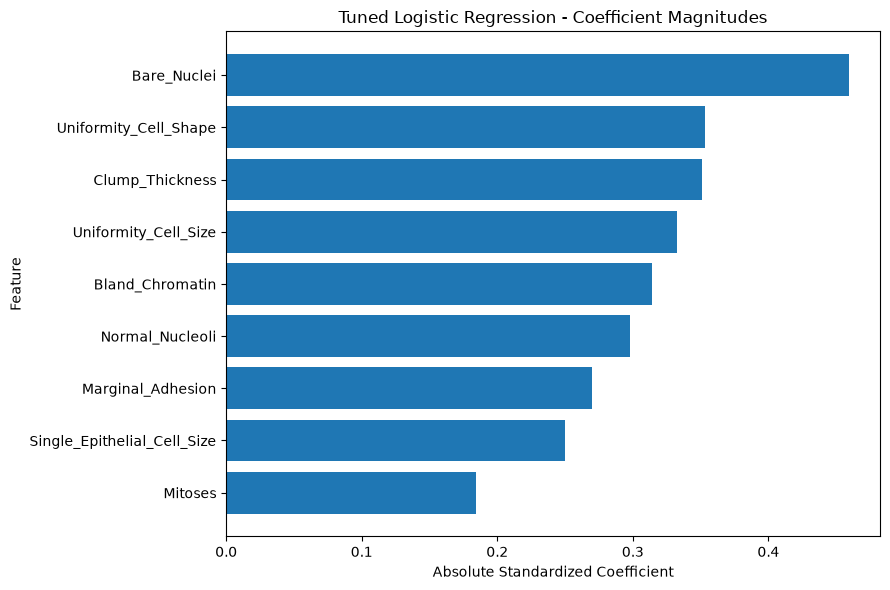

In [50]:
# ============================================================
# PLOT LOGISTIC REGRESSION COEFFICIENT MAGNITUDES
# ============================================================

# Create a horizontal bar chart showing the absolute
# magnitude of each standardized coefficient.
plt.figure(
    figsize=(9, 6)
)


plt.barh(
    lr_coefficient_df["Feature"],
    lr_coefficient_df["Absolute_Coefficient"]
)


# Reverse the y-axis so the largest coefficient appears
# at the top of the graph.
plt.gca().invert_yaxis()


# Add descriptive labels.
plt.xlabel(
    "Absolute Standardized Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Tuned Logistic Regression - Coefficient Magnitudes"
)


# Improve spacing.
plt.tight_layout()


# Display the graph.
plt.show()

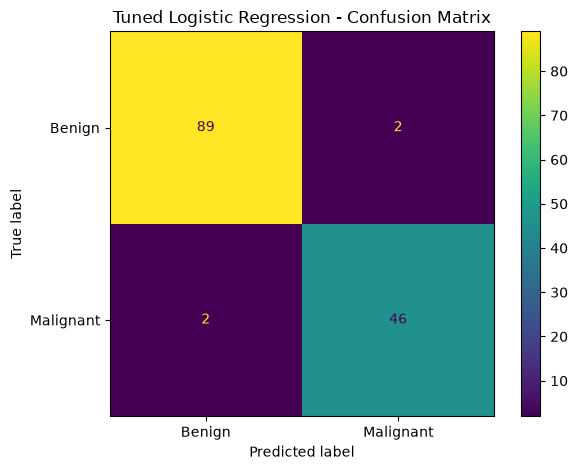

In [51]:
# ============================================================
# DISPLAY TUNED LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# Create the confusion-matrix visualization directly
# from the tuned predictions.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_tuned,
    display_labels=[
        "Benign",
        "Malignant"
    ]
)


# Add a descriptive title.
plt.title(
    "Tuned Logistic Regression - Confusion Matrix"
)


# Improve layout.
plt.tight_layout()


# Display the plot.
plt.show()

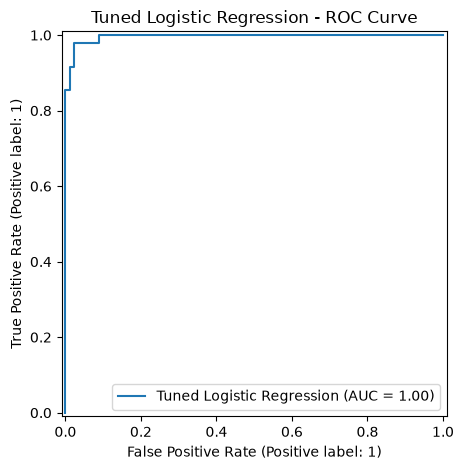

In [52]:
# ============================================================
# PLOT ROC CURVE FOR TUNED LOGISTIC REGRESSION
# ============================================================

# Create the ROC curve using the tuned model's
# predicted probabilities.
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr_tuned,
    name="Tuned Logistic Regression"
)


# Add a descriptive title.
plt.title(
    "Tuned Logistic Regression - ROC Curve"
)


# Improve layout.
plt.tight_layout()


# Display the ROC curve.
plt.show()

In [53]:
# ============================================================
# CREATE CROSS-VALIDATION SUMMARY
# ============================================================

# Store the mean cross-validation results for the
# baseline and tuned Logistic Regression models.
lr_cv_summary = pd.DataFrame({

    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],

    "Accuracy_Mean": [
        cv_results_lr["test_accuracy"].mean(),
        lr_tuned_cv_results["test_accuracy"].mean()
    ],

    "Precision_Mean": [
        cv_results_lr["test_precision"].mean(),
        lr_tuned_cv_results["test_precision"].mean()
    ],

    "Recall_Mean": [
        cv_results_lr["test_recall"].mean(),
        lr_tuned_cv_results["test_recall"].mean()
    ],

    "F1_Mean": [
        cv_results_lr["test_f1"].mean(),
        lr_tuned_cv_results["test_f1"].mean()
    ],

    "ROC_AUC_Mean": [
        cv_results_lr["test_roc_auc"].mean(),
        lr_tuned_cv_results["test_roc_auc"].mean()
    ]
})


print(
    "Logistic Regression Cross-Validation Summary:"
)

display(
    lr_cv_summary.round(4)
)

Logistic Regression Cross-Validation Summary:


,Model,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean
0,Baseline Logistic Regression,0.9692,0.9535,0.9579,0.9553,0.9947
1,Tuned Logistic Regression,0.9692,0.9443,0.9684,0.9557,0.9941


## Final Logistic Regression Conclusion

Two main Logistic Regression varieties were evaluated: a baseline model and
a hyperparameter-tuned model.

For hyperparameter tuning, 30 configurations were evaluated using
GridSearchCV with 5-fold stratified cross-validation. The configurations
varied the regularization strength (C), regularization type, solver, and
class weighting.

The optimum configuration selected according to cross-validation F1-score
was:

- C = 0.01
- Penalty = L2
- Solver = liblinear
- Class weight = None
- Best cross-validation F1 = 0.9557

On the held-out test set, the tuned Logistic Regression achieved:

- Accuracy = 0.9712
- Precision = 0.9583
- Recall = 0.9583
- F1-score = 0.9583
- ROC-AUC = 0.9961

The tuned model produced 89 true negatives, 2 false positives, 2 false
negatives, and 46 true positives.

Compared with the baseline model, tuning increased test recall from 0.9167
to 0.9583 and reduced false negatives from 4 to 2. Precision decreased from
0.9778 to 0.9583, showing a trade-off between detecting more malignant cases
and producing slightly more false-positive predictions.

The tuned Logistic Regression was retained as Member 04's final
configuration because it was selected using cross-validated F1-score and
also produced stronger held-out recall and F1-score.

Although the results are strong on this dataset, they should not be
interpreted as evidence that the model is ready for clinical use. The
dataset is relatively small and historical, so further validation on
independent and more diverse data would be required.

In [54]:
# ============================================================
# SAVE MEMBER 04 LOGISTIC REGRESSION RESULTS
# ============================================================

# Create a dedicated Member 04 folder inside the shared
# results/outputs directory required by the repository structure.
member04_results_dir = (
    PROJECT_ROOT
    / "results"
    / "outputs"
    / "member_04"
)

# Create the directory if it does not already exist.
member04_results_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE BASELINE VS TUNED TEST RESULTS
# ------------------------------------------------------------

# Save the baseline vs tuned Logistic Regression comparison.
lr_comparison.to_csv(
    member04_results_dir
    / "logistic_regression_baseline_vs_tuned.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE CROSS-VALIDATION SUMMARY
# ------------------------------------------------------------

# Save the cross-validation performance summary.
lr_cv_summary.to_csv(
    member04_results_dir
    / "logistic_regression_cross_validation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE COMPLETE GRID SEARCH RESULTS
# ------------------------------------------------------------

# Save all Logistic Regression hyperparameter search results.
lr_grid_results.to_csv(
    member04_results_dir
    / "logistic_regression_grid_search_results.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE TOP GRID SEARCH CONFIGURATIONS
# ------------------------------------------------------------

# Save the ten strongest hyperparameter configurations.
lr_top_results.head(10).to_csv(
    member04_results_dir
    / "logistic_regression_top_configurations.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE LOGISTIC REGRESSION COEFFICIENTS
# ------------------------------------------------------------

# Save the feature coefficients from Logistic Regression.
lr_coefficient_df.to_csv(
    member04_results_dir
    / "logistic_regression_coefficients.csv",
    index=False
)


# ============================================================
# CONFIRM SAVED FILES
# ============================================================

# Confirm that all Member 04 results were saved successfully.
print("Member 04 results saved successfully.")

print(
    "\nResults directory:",
    member04_results_dir
)

print("\nSaved files:")

# Display all CSV files saved for Member 04.
for file_path in sorted(
    member04_results_dir.glob("*.csv")
):
    print(
        "-",
        file_path.name
    )

Member 04 results saved successfully.

Results directory: c:\Users\gayan\Documents\AI\results\outputs\member_04

Saved files:
- logistic_regression_baseline_vs_tuned.csv
- logistic_regression_coefficients.csv
- logistic_regression_cross_validation_summary.csv
- logistic_regression_grid_search_results.csv
- logistic_regression_top_configurations.csv
